In [1]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import numpy as np
from common_utils import NeuralNetwork, NeuralNetwork_dropout, EarlyStopper
from common_utils import train_loop, test_loop
from common_utils import device, set_seed

In [2]:
batch_size = 256
max_epochs = 100

lr = 0.001
patience = 10
dropouts = 0.4
hidden_size = 400

set_seed(0)
print(f"Using {device} device")

Using mps device


In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

In [4]:
model = NeuralNetwork(hidden_size=hidden_size).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = lr)
early_stopper = EarlyStopper(patience=patience, min_delta=0)

tr_loss, tr_correct = [], []
te_loss, te_correct = [], []
for t in range(max_epochs):
    
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)

    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr_loss.append(train_loss), tr_correct.append(train_correct)
    te_loss.append(test_loss), te_correct.append(test_correct)
    
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 41.06%, Train_loss: 0.006517, Test_accuracy: 46.60%, Test_loss: 0.005992
Epoch 2: Train_accuracy: 49.77%, Train_loss: 0.005564, Test_accuracy: 51.17%, Test_loss: 0.005571
Epoch 3: Train_accuracy: 54.11%, Train_loss: 0.005097, Test_accuracy: 51.67%, Test_loss: 0.005519
Epoch 4: Train_accuracy: 57.67%, Train_loss: 0.004680, Test_accuracy: 53.74%, Test_loss: 0.005248
Epoch 5: Train_accuracy: 60.66%, Train_loss: 0.004329, Test_accuracy: 52.51%, Test_loss: 0.005476
Epoch 6: Train_accuracy: 63.93%, Train_loss: 0.003972, Test_accuracy: 53.88%, Test_loss: 0.005436
Epoch 7: Train_accuracy: 66.73%, Train_loss: 0.003641, Test_accuracy: 54.22%, Test_loss: 0.005510
Epoch 8: Train_accuracy: 69.75%, Train_loss: 0.003285, Test_accuracy: 55.49%, Test_loss: 0.005567
Epoch 9: Train_accuracy: 73.22%, Train_loss: 0.002923, Test_accuracy: 54.04%, Test_loss: 0.005930
Epoch 10: Train_accuracy: 76.29%, Train_loss: 0.002617, Test_accuracy: 54.44%, Test_loss: 0.006321
Epoch 11: Train_acc

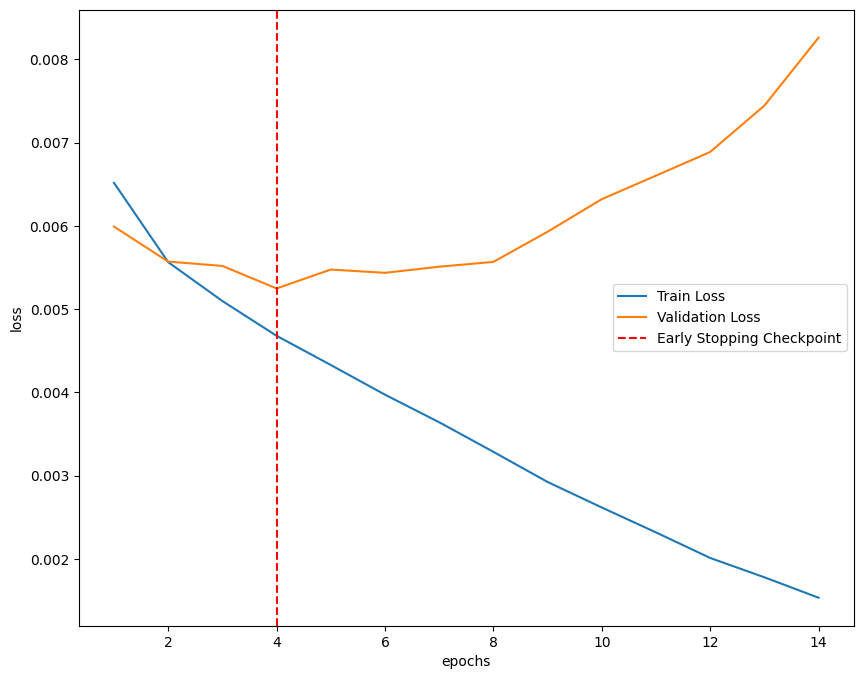

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
plt.plot(range(1,len(tr_loss)+1),tr_loss, label='Train Loss')
plt.plot(range(1,len(te_loss)+1),te_loss,label='Validation Loss')

# find position of lowest validation loss
minposs = te_loss.index(min(te_loss))+1 
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [9]:
dropouts = 0.4
model = NeuralNetwork_dropout(hidden_size=hidden_size, drop_out = dropouts).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = lr)
early_stopper = EarlyStopper(patience=patience, min_delta=0)

tr2_loss, tr2_correct = [], []
te2_loss, te2_correct = [], []
for t in range(max_epochs):
    model.train()
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)

    model.eval()
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr2_loss.append(train_loss), tr2_correct.append(train_correct)
    te2_loss.append(test_loss), te2_correct.append(test_correct)
    
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 34.72%, Train_loss: 0.007125, Test_accuracy: 43.30%, Test_loss: 0.006424
Epoch 2: Train_accuracy: 41.83%, Train_loss: 0.006454, Test_accuracy: 46.94%, Test_loss: 0.006071
Epoch 3: Train_accuracy: 44.35%, Train_loss: 0.006165, Test_accuracy: 48.88%, Test_loss: 0.005835
Epoch 4: Train_accuracy: 45.92%, Train_loss: 0.005989, Test_accuracy: 49.41%, Test_loss: 0.005792
Epoch 5: Train_accuracy: 47.09%, Train_loss: 0.005857, Test_accuracy: 51.22%, Test_loss: 0.005611
Epoch 6: Train_accuracy: 48.36%, Train_loss: 0.005718, Test_accuracy: 50.83%, Test_loss: 0.005582
Epoch 7: Train_accuracy: 49.59%, Train_loss: 0.005591, Test_accuracy: 51.83%, Test_loss: 0.005475
Epoch 8: Train_accuracy: 50.65%, Train_loss: 0.005495, Test_accuracy: 52.53%, Test_loss: 0.005431
Epoch 9: Train_accuracy: 51.16%, Train_loss: 0.005426, Test_accuracy: 52.33%, Test_loss: 0.005399
Epoch 10: Train_accuracy: 51.83%, Train_loss: 0.005348, Test_accuracy: 52.91%, Test_loss: 0.005396
Epoch 11: Train_acc

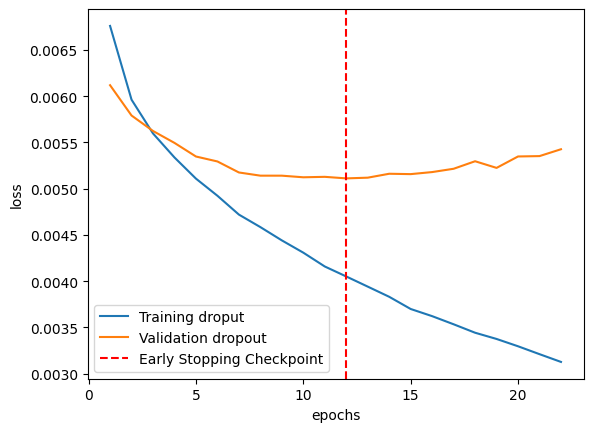

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1,len(tr2_loss)+1),tr2_loss, label='Training droput')
plt.plot(range(1,len(te2_loss)+1),te2_loss,label='Validation dropout')

# find position of lowest validation loss
minposs = te2_loss.index(min(te2_loss))+1 
plt.axvline(minposs, linestyle='--', color='r',label='Early Stopping Checkpoint')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

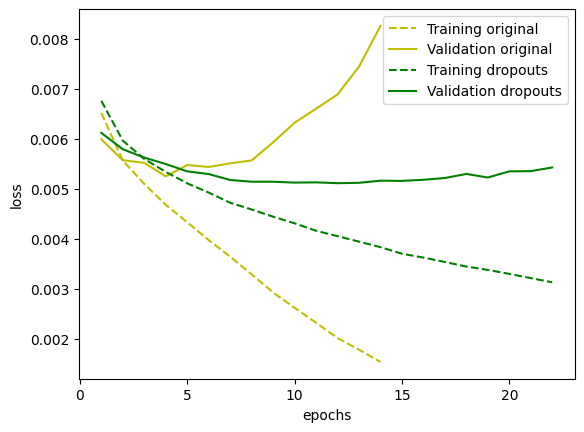

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1,len(tr_loss)+1),tr_loss, linestyle = '--', color = 'y', label='Training original')
plt.plot(range(1,len(te_loss)+1),te_loss, color = 'y', label='Validation original')
plt.plot(range(1,len(tr2_loss)+1),tr2_loss, linestyle = '--', color = 'g', label='Training dropouts')
plt.plot(range(1,len(te2_loss)+1),te2_loss, color = 'g', label='Validation dropouts')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()